In [3]:
import numpy as np
import matplotlib.pyplot as plt

path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"

path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha2_Loc5_True19_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha2_Loc5_True19_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha2_Loc5_True19_kindFULL_2D.npz'

data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)

xa1    = data1['xa'][:]
yo1    = data1['yo'][:]
atemp1 = data1['steps'][:]
ox1,oy1,oz1 = data1['ox'][:], data1['oy'][:], data1['oz'][:]
deps1 = data1['deps'][:]
print('deps1', deps1.shape)
print('Shape xa1', xa1.shape)
print(f'yo {yo1.shape}')
print(f'steps {atemp1}')

xa2    = data2['xa'][:]
yo2    = data2['yo'][:]
atemp2 = data2['steps'][:]
ox2,oy2,oz2 = data2['ox'][:], data2['oy'][:], data2['oz'][:]
deps2 = data2['deps'][:]
print('Shape xa2', xa2.shape)
print(f'yo {yo2.shape}')
print(f'steps {atemp2}')

xa3    = data3['xa'][:]
yo3    = data3['yo'][:]
atemp3 = data3['steps'][:]
ox3,oy3,oz3 = data3['ox'][:], data3['oy'][:], data3['oz'][:]
deps3 = data3['deps'][:]
print('Shape xa3', xa3.shape)
print(f'yo3 {yo3.shape}')
print(f'steps {atemp3}')

deps1 (1, 43)
Shape xa1 (77, 1, 43, 29, 8)
yo (43,)
steps [1.]
Shape xa2 (77, 1, 43, 29, 8)
yo (43,)
steps [0.04742587 0.95257413]
Shape xa3 (77, 1, 43, 29, 8)
yo3 (43,)
steps [0.00380626 0.20781451 0.78837925]


In [4]:
import sys, pathlib
REPO_ROOT = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/fortran"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from cletkf_wloc import common_da as cda

truth = data1['truth'][:]
xn,yn,zn = xa1.shape[0:3]
ref = np.zeros((xn,yn,zn))
for xi in np.arange(xn):
    for yi in np.arange(yn):
        for zi in np.arange(zn):
            qr = truth[xi, yi, zi, 1]
            qs = truth[xi, yi, zi, 2]
            qg = truth[xi, yi, zi, 0]
            tt = truth[xi, yi, zi, 3]
            pp = truth[xi, yi, zi, 4]

            ref[xi,yi,zi] = cda.calc_ref(qr, qs, qg, tt, pp)

In [ ]:
def tight_bbox_from_field(field2d, threshold=0.0, pad=2):
    """
    Return (xmin, xmax, zmin, zmax) axis limits in index space for
    the region where field2d > threshold. pad is in grid cells.
    """
    a = np.asarray(field2d)
    mask = a > threshold
    if not np.any(mask):
        # fall back to full domain
        xn, zn = a.shape
        return -0.5, xn - 0.5, -0.5, zn - 0.5
    ix, iz = np.where(mask)           # ix ~ x-index (first dim), iz ~ z-index (second dim)
    xn, zn = a.shape
    xmin = max(ix.min() - pad, 0)
    xmax = min(ix.max() + pad, xn - 1)
    zmin = max(iz.min() - pad, 0)
    zmax = min(iz.max() + pad, zn - 1)
    # use half-cell edges for pretty bounds
    return xmin - 0.5, xmax + 0.5, zmin - 0.5, zmax + 0.5

def plot_observations(data):
    truth = data['truth'][:]
    xa    = data['xa'][:]
    hxf   = data['hxf'][:]
    xn,yn,zn = xa.shape[0:3]
    yo1    = data['yo'][:]
    atemp1 = data['steps'][:]
    ox1,oy1,oz1 = data['ox'][:], data['oy'][:], data['oz'][:]
    deps1 = data['deps'][:]
    ref = np.zeros((xn,yn,zn))
    for xi in np.arange(xn):
        for yi in np.arange(yn):
            for zi in np.arange(zn):
                qr = truth[xi, yi, zi, 1]
                qs = truth[xi, yi, zi, 2]
                qg = truth[xi, yi, zi, 0]
                tt = truth[xi, yi, zi, 3]
                pp = truth[xi, yi, zi, 4]

                ref[xi,yi,zi] = cda.calc_ref(qr, qs, qg, tt, pp)
    ref2d = ref[:,0,:]
    xmin, xmax, zmin, zmax = tight_bbox_from_field(ref2d, threshold=5.0, pad=2)

    fig, ax = plt.subplots(1, 3, figsize=(20, 4.5),dpi=300, facecolor='white')
    im=ax[0].scatter(ox1,oz1,c=yo1,cmap='Spectral_r', marker='o', s=35,vmin=5,vmax=40)

    fig.colorbar(im, ax=ax[0], label="Reflectivity (dBZ)")
    ax[0].set_title(f'Observations  $[y_0] (Nobs = {len(yo1)})$',fontsize=20)
    ax[0].set_aspect('equal','box')

    X, Z = np.meshgrid(np.arange(xn), np.arange(zn), indexing='ij')
    #im3 = ax[1].scatter(X.flatten(), Z.flatten(), c=ref[:,0,:].flatten(), cmap='Spectral_r', marker='o', s=10,vmin=0,vmax=50)
    #im2 = ax[1].pcolormesh(X, Z, hxf, cmap="Spectral_r", vmin=5, vmax=40, shading='auto')
    im2  = ax[1].scatter(ox1, oz1, c=np.nanmean(hxf[0,:,:],axis=1),cmap='Spectral_r', marker='o', s=35,vmin=5,vmax=40)
    #cd  = ax[1].scatter(ox1, oz1, s=12, color="white", alpha=0.6, edgecolor="none", rasterized=True)
    fig.colorbar(im2, ax=ax[1], label="Reflectivity (dBZ)")
    ax[1].set_title('Ensemble mean $ [\overline{ H[x_f] }]$',fontsize=20)
    ax[1].set_aspect('equal','box')

    im=ax[2].scatter(ox1,oz1,c=deps1,cmap='RdBu_r', marker='o', edgecolor="k", s=35,vmin=-20,vmax=20)

    fig.colorbar(im, ax=ax[2], label="Reflectivity (dBZ)")
    ax[2].set_title('Departure $[y_0 - \overline{ H[x_f] }]$',fontsize=20)
    ax[2].set_aspect('equal','box')

    xmin, xmax, zmin, zmax = tight_bbox_from_field(ref2d, threshold=5.0, pad=2)

    for a in ax:
        a.set_xlim(xmin, xmax)
        a.set_ylim(zmin, zmax)
        a.set_aspect('equal', 'box')
        cs = a.contour(ref2d.T,levels = [5,10], colors="k", linewidths=0.8)
        a.clabel(cs, fmt="%.0f", inline=True, fontsize=8)
    plt.tight_layout()
    plt.savefig('Observations_EnsembleMean_Departure.png', dpi=300)



    plt.show()

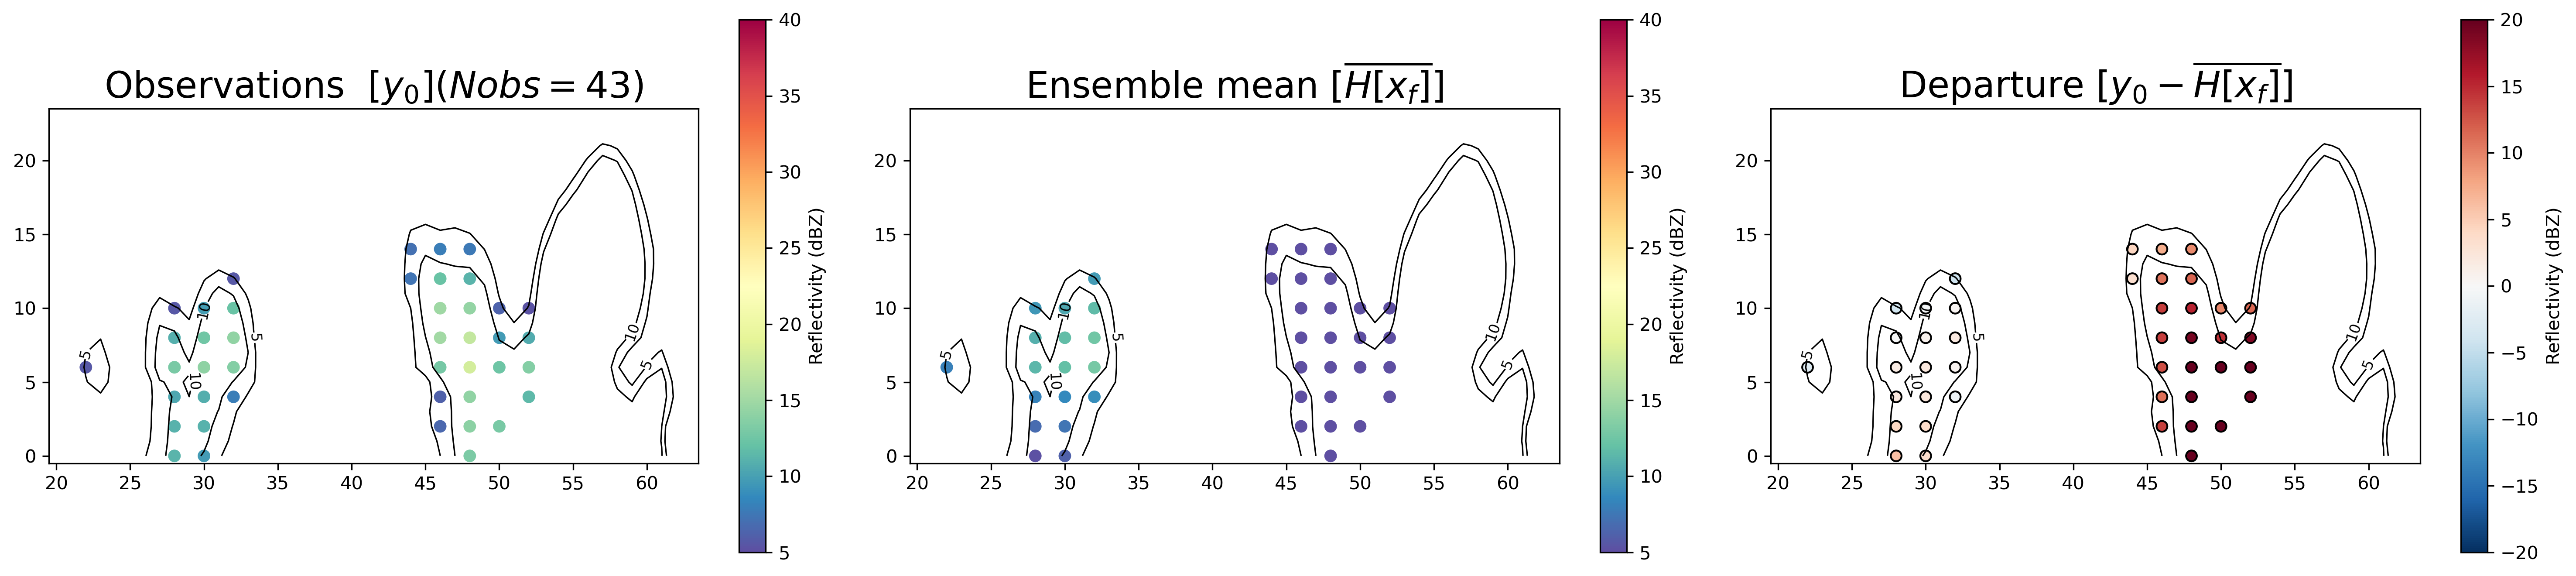

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sys, pathlib
REPO_ROOT = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/fortran"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from cletkf_wloc import common_da as cda
path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"
alpha=2
loc=5
true=19                
path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'

data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)
plot_observations(data1)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def plot_error_analysis(data1, data2, data3):
    # Define file paths
    truth = data1['truth'][:]
    xa    = data1['xa'][:]
    xn,yn,zn = xa.shape[0:3]
    ref = np.zeros((xn,yn,zn))
    for xi in np.arange(xn):
        for yi in np.arange(yn):
            for zi in np.arange(zn):
                qr = truth[xi, yi, zi, 1]
                qs = truth[xi, yi, zi, 2]
                qg = truth[xi, yi, zi, 0]
                tt = truth[xi, yi, zi, 3]
                pp = truth[xi, yi, zi, 4]

                ref[xi,yi,zi] = cda.calc_ref(qr, qs, qg, tt, pp)
    ref2d = ref[:,0,:]
    file_paths = {
        'LETKF'   : data1,
        'LETKF-T2': data2,
        'LETKF-T3': data3
    }

    # Variable names
    variables = {
        0: 'Graupel',
        3: 'Temperature',
        7: 'Vertical Wind'
    }

    fig, axs = plt.subplots(3, 3, figsize=(18, 12), facecolor='white')
    for i, (var_index, var_name) in enumerate(variables.items()):
        contour_levels = {}  # Store contour levels and ticks per row
        err_maxs = []
        for col_index, (col_name, data) in enumerate(file_paths.items()):
            xa = data['xa'][:, 0, :, :, :]
            true_state = data['truth'][:, 0, :, :]
            mean_xa = np.nanmean(xa, axis=2)
            analysis_field = mean_xa[:, :, var_index]
            true_field = true_state[:, :, var_index]
            idx_zero = true_field == 0
            true_field[idx_zero] = np.nan  # Set to NaN to avoid division by zero
            error_analysis = analysis_field - true_field        #print(f'Error analysis shape: {error_analysis}')
            err_maxs.append(np.nanmax(np.abs(error_analysis)))

        err_max = np.nanmax(err_maxs)
        contour_levels['error'] = np.linspace(-err_max, err_max, 20)

        for col_index, (col_name, data) in enumerate(file_paths.items()):
            xa = data['xa'][:, 0, :, :, :]
            true_state = data['truth'][:, 0, :, :]
            mean_xa = np.nanmean(xa, axis=2)
            analysis_field = mean_xa[:, :, var_index]
            true_field = true_state[:, :, var_index]
            # Avoid division by zero

            error_analysis = analysis_field - true_field
            # Analysis Error
            im = axs[i, col_index].contourf(error_analysis.T, cmap='RdBu_r', levels=contour_levels['error'])
            cb2 = fig.colorbar(im, ax=axs[i, col_index])
            rmse = np.sqrt(mean_squared_error(true_field, analysis_field))
            axs[i, col_index].set_title(f"{col_name} | RMSE: {rmse:.3f} ",fontsize=20)
            cs = axs[i, col_index].contour(ref2d.T,levels = [5,10], colors="k", linewidths=0.8)
            axs[i, col_index].clabel(cs, fmt="%.0f", inline=True, fontsize=12)
            # Grid every 2 units and add square
            for ax in axs[:, col_index]:
                ax.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)
                #ax.set_xticks(np.arange(0, forecast_field.shape[0], 5))
                #ax.set_yticks(np.arange(0, forecast_field.shape[1], 5))
            if col_index == 0:
                axs[i, col_index].set_ylabel(f"{var_name}", fontsize=20)
        # General title
        #fig.suptitle(f"Variable: {var_name}", fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('Error_Analysis_Multiple_Obs.png', dpi=300,transparent=False)
    plt.show()

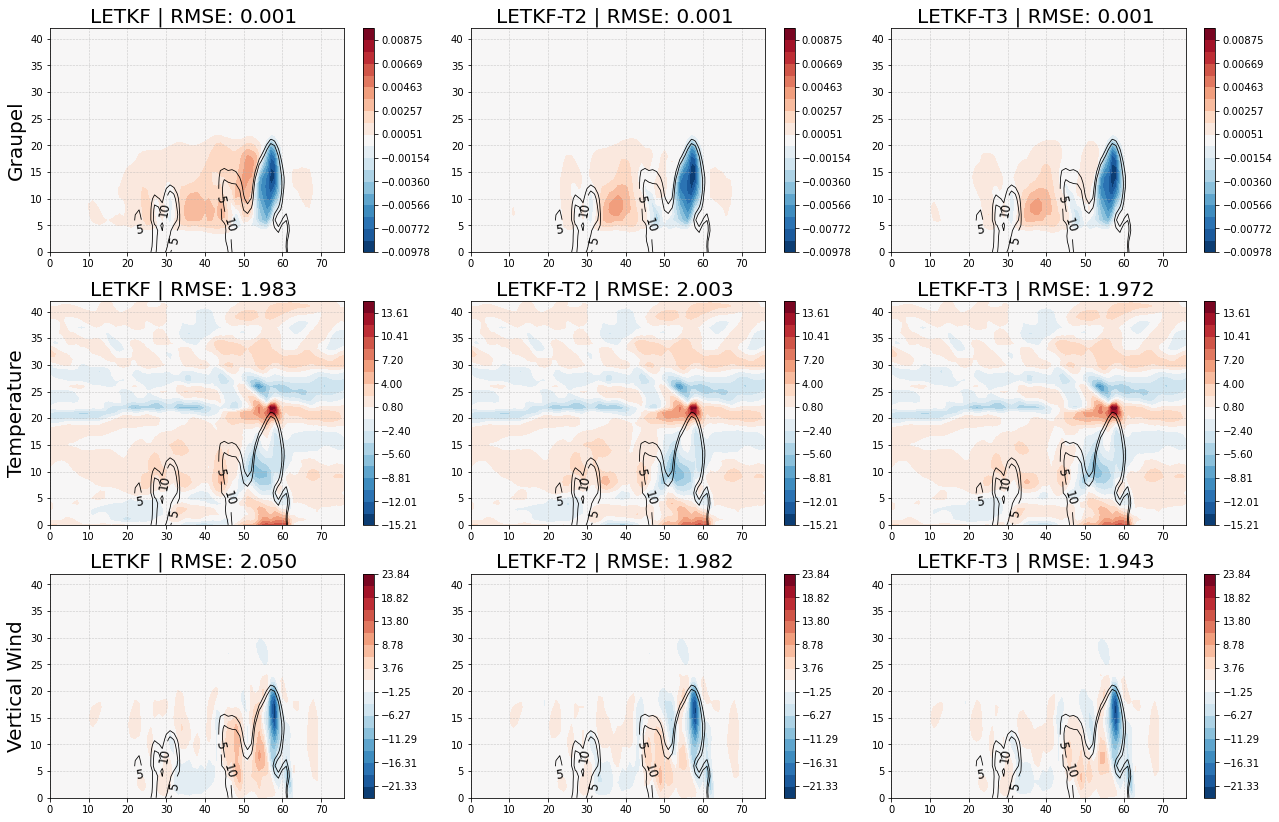

In [15]:
path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"
figpath_error = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/error/"
figpath_obs = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/observations/"
alpha_range = [0,1,2,3]
loc_range = [-1,1,2,3,4,5,6,7,8,9,10]
nens_range = np.arange(30)

alpha=2
loc=5
true=19                
path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)
plot_error_analysis(data1, data2, data3)

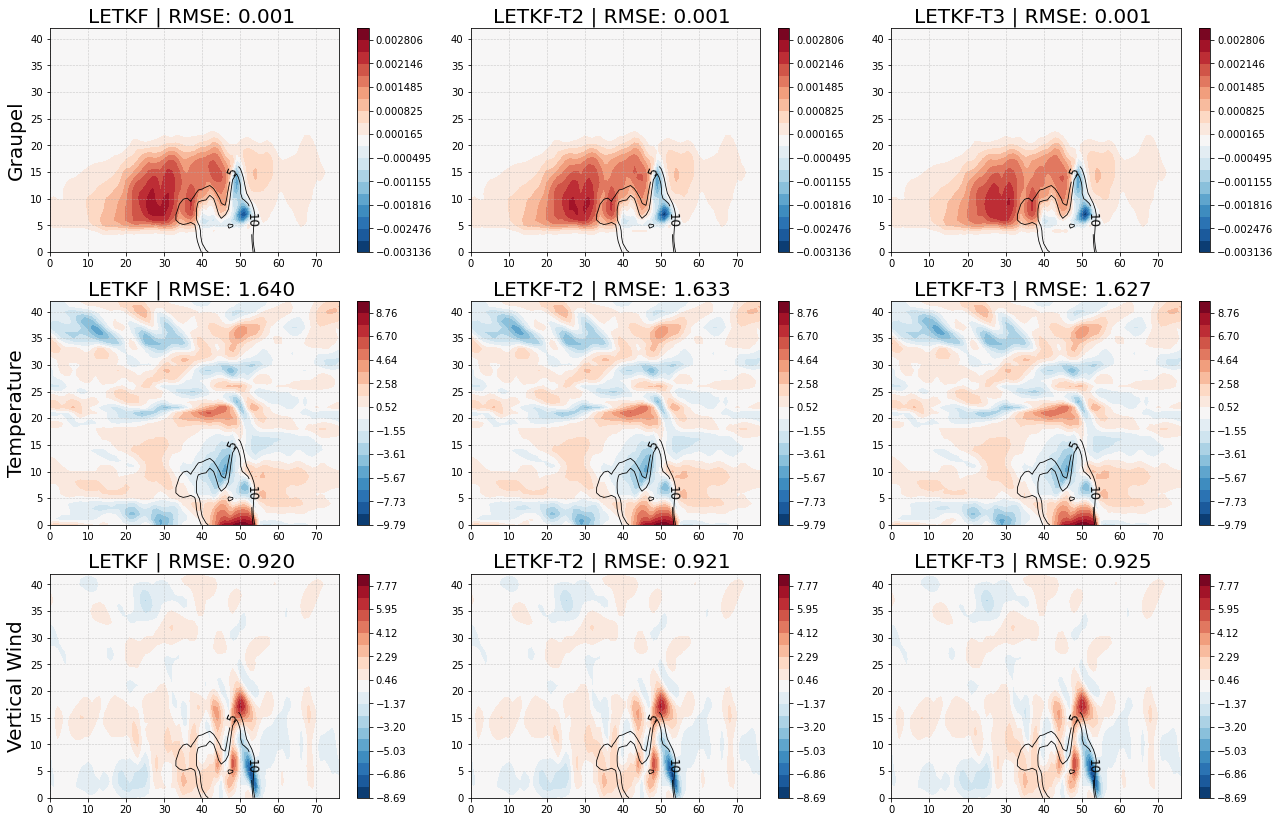

In [ ]:
path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"
figpath_error = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/error/"
figpath_obs = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/observations/"
alpha_range = [0,1,2,3]
loc_range = [-1,1,2,3,4,5,6,7,8,9,10]
nens_range = np.arange(30)

alpha=0
loc=10
true=5                
path1 =  f'{path}Multicycle_v1_2023-12-16_19:00:00_temp1_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v1_2023-12-16_19:00:00_temp2_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v1_2023-12-16_19:00:00_temp3_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)
plot_error_analysis(data1, data2, data3)

In [9]:
import numpy as np
import os

# --- Load a run (NPZ + any split NPYs) --------------------------------------
run_dir = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle"
tag     = "Multicycle_v1_2023-12-16_19:00:00_temp3_alpha2_kindFULL_2D"   # change per file
npz     = np.load(os.path.join(run_dir, f"{tag}.npz"), allow_pickle=True)

def _maybe_npy(key):
    p = os.path.join(run_dir, f"{tag}__{key}.npy")
    return np.load(p, mmap_mode="r") if os.path.exists(p) else npz[key]

xatemp = _maybe_npy("xa")   # (nx,ny,nz,Ne,nvar, ntemp+1)
hxfs   = _maybe_npy("hxf")     # (ntemp, nobs, Ne)
deps   = npz.get("deps")        # (ntemp, nobs)  -- optional
yo     = npz["yo"].astype("float32")   # (nobs,)
oerr   = npz["obs_error"].astype("float32")  # scalar or (nobs,)
ox,oy,oz = npz["ox"], npz["oy"], npz["oz"]   # filtered obs coords (0-based)

steps  = npz["steps"].astype("float32")      # tempering alphas
ntemp  = xatemp.shape[-1]-1
nx,ny,nz,Ne,nvar = xatemp.shape
nobs   = yo.size

print(f"xatemp {xatemp.shape}, hxfs {hxfs.shape}, nobs={nobs}, Ne={Ne}, ntemp={ntemp}")

# --- Recompute H(x_a) at final analysis for the obs points -------------------
# We need your var indices & radar operator, but we can re-use hxf’s pattern.
# Quick inline H: same as used to build hxfs, applied to final analysis.
from types import SimpleNamespace

# Pull indices if they were saved; otherwise define manually
var_idx = dict(npz["var_idx"].item()) if "var_idx" in npz.files else {
    "qr":0,"qs":1,"qg":2,"T":3,"P":4  # adjust to your saved order
}

# Lightweight reflectivity operator (must match your Fortran/Python one)
def calc_ref(qr, qs, qg, T, P):
    # You should replace by your exact operator; this placeholder mirrors your use.
    # Using sum of hydrometeors as a proxy to keep the diagnostic consistent.
    return (qr + qs + qg) * 1e6

# Final analysis state
Xa_last = xatemp  # (nx,ny,nz,Ne,nvar)

# Build H(X_f) ensemble mean from saved hxfs (step 0 entries are forecast)
Hxf_mean = hxfs[0].mean(axis=1).astype("float32") if hxfs.shape[0] > 0 else None

# Build H(X_a) at final step
Hxa = np.zeros((nobs, Ne), dtype="float32")
for ii in range(nobs):
    i,j,k = int(ox[ii]), int(oy[ii]), int(oz[ii])
    qr = Xa_last[i,j,k,:,var_idx["qr"]]
    qs = Xa_last[i,j,k,:,var_idx["qs"]]
    qg = Xa_last[i,j,k,:,var_idx["qg"]]
    TT = Xa_last[i,j,k,:,var_idx["T"]]
    PP = Xa_last[i,j,k,:,var_idx["P"]]
    Hxa[ii,:] = calc_ref(qr, qs, qg, TT, PP)

Hxa_mean = Hxa.mean(axis=1)

# --- Diagnostics -------------------------------------------------------------
d_f = yo - Hxf_mean           # forecast innovation
d_a = yo - Hxa_mean           # analysis innovation

# If oerr is scalar, broadcast
if np.ndim(oerr) == 0: oerr = np.full(nobs, float(oerr), dtype="float32")

z_f = d_f / oerr
z_a = d_a / oerr

NIS_f = float(np.sum(z_f**2))
NIS_a = float(np.sum(z_a**2))

print(f"Mean|d_f|={np.mean(np.abs(d_f)):.3f},  Mean|d_a|={np.mean(np.abs(d_a)):.3f}")
print(f"NIS_f={NIS_f:.1f} (expect ~{nobs}),  NIS_a={NIS_a:.1f}")

# Spread vs RMSE at obs locations, forecast vs analysis
# (Compute ensemble std of Hx and RMSE vs truth? Here use innovation proxy)
Hx_f_std = hxfs[0].std(axis=1) if hxfs.shape[0] > 0 else np.full(nobs, np.nan,"float32")
Hx_a_std = Hxa.std(axis=1)

# Ratios (use absolute innovation as proxy for RMSE at obs point)
ratio_f = np.nanmean(Hx_f_std / (np.abs(d_f)+1e-6))
ratio_a = np.nanmean(Hx_a_std / (np.abs(d_a)+1e-6))
print(f"Spread/RMSE ~ forecast: {ratio_f:.2f}, analysis: {ratio_a:.2f}")

# Directional consistency: increments should oppose innovation
# (sign of Hxa_mean - Hxf_mean should be opposite to sign of d_f)
incr = Hxa_mean - Hxf_mean
agree = np.mean(np.sign(incr) == -np.sign(d_f))
print(f"Increments oppose innovations in {agree*100:.1f}% of obs (higher is better).")


FileNotFoundError: [Errno 2] No such file or directory: '/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/Multicycle_v1_2023-12-16_19:00:00_temp3_alpha2_kindFULL_2D.npz'

In [ ]:
# use the exact same Fortran module the DA used
try:
    # if your project has the helper:
    from da.fortran_interpreter import _import_fortran
    cda = _import_fortran()
except Exception:
    import sys, os
    # add the fortran build folder that contains cletkf_wloc/common_da*.so
    sys.path.insert(0, "/home/jorge.gacitua/datosdemerzel/wrf_python_Assimilation/fortran")
    from cletkf_wloc import common_da as cda

# correct ntemp from hxfs, and confirm shapes
ntemp = hxfs.shape[0]
print(f"hxfs ntemp={ntemp}, hxfs={hxfs.shape}, xa={xatemp.shape}")

# var indices (ensure this matches the DA run)
var_idx = {
        "qg": 0,
        "qr": 1,
        "qs": 2,
        "T": 3,
        "P": 4,
        "u": 5,
        "v": 6,
        "w": 7
      }
Xa = xatemp  # (nx,ny,nz,Ne,nvar)

# Recompute H(x_a) with the SAME operator (Fortran)
Hxa = np.zeros((nobs, Ne), dtype="float32")
for ii in range(nobs):
    i,j,k = int(ox[ii]), int(oy[ii]), int(oz[ii])
    qr = Xa[i,j,k,:,var_idx["qr"]]; qs = Xa[i,j,k,:,var_idx["qs"]]
    qg = Xa[i,j,k,:,var_idx["qg"]]; TT = Xa[i,j,k,:,var_idx["T"]]
    PP = Xa[i,j,k,:,var_idx["P"]]
    # Fortran calc_ref expects scalars; loop over members
    for m in range(Ne):
        Hxa[ii, m] = cda.calc_ref(qr[m], qs[m], qg[m], TT[m], PP[m])

Hxf_mean = hxfs[0].mean(axis=1).astype("float32")
Hxa_mean = Hxa.mean(axis=1).astype("float32")

d_f = yo - Hxf_mean
d_a = yo - Hxa_mean

# Broadcast obs error if scalar; use STD (same units as yo)
oerr_arr = oerr if oerr.ndim == 1 else np.full(nobs, float(oerr), dtype="float32")
z_f = d_f / oerr_arr; z_a = d_a / oerr_arr
NIS_f = float(np.sum(z_f**2)); NIS_a = float(np.sum(z_a**2))

print(f"Mean|d_f|={np.mean(np.abs(d_f)):.3f},  Mean|d_a|={np.mean(np.abs(d_a)):.3f}")
print(f"NIS_f={NIS_f:.1f} (expect ~{nobs}),  NIS_a={NIS_a:.1f}")

Hx_f_std = hxfs[0].std(axis=1)
Hx_a_std = Hxa.std(axis=1)
ratio_f = float(np.nanmean(Hx_f_std / (np.abs(d_f)+1e-6)))
ratio_a = float(np.nanmean(Hx_a_std / (np.abs(d_a)+1e-6)))
print(f"Spread/RMSE ~ forecast: {ratio_f:.2f}, analysis: {ratio_a:.2f}")

incr = Hxa_mean - Hxf_mean
agree = np.mean(np.sign(incr) == -np.sign(d_f))
print(f"Increments oppose innovations in {agree*100:.1f}% of obs.")


hxfs ntemp=3, hxfs=(3, 60, 29), xa=(77, 1, 43, 29, 8)
Mean|d_f|=9.530,  Mean|d_a|=11.221
NIS_f=290.0 (expect ~60),  NIS_a=408.2
Spread/RMSE ~ forecast: 5.10, analysis: 3.88
Increments oppose innovations in 76.7% of obs.
